In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [38]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\spam.csv", encoding='latin-1')
df = df[['spamORham', 'Message']]
df.columns = ['label', 'text']
print(f"Dataset Shape: {df.shape}")
print("\nClass Distribution:\n", df['label'].value_counts())
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [39]:
X_train, X_test, y_train, y_test=train_test_split(df['text'],df['label'], test_size=0.2, random_state=42, stratify=df['label'])
MAX_WORDS=5000
MAX_LEN=50
EMBEDDING_DIM=64
tokenizer=Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)
X_train_pad=pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad=pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [40]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
        Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),
        GRU(
        units=64,
        dropout=0.2,
        recurrent_dropout=0.2,
        return_sequences=False
    ),
        Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 64)              │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,073 (1.32 MB)

 Trainable params: 347,073 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print("\nStarting Model Training...")
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


Starting Model Training...
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.8674 - loss: 0.4354 - val_accuracy: 0.8453 - val_loss: 0.4372
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8681 - loss: 0.4063 - val_accuracy: 0.8453 - val_loss: 0.4423
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8681 - loss: 0.4013 - val_accuracy: 0.8453 - val_loss: 0.4333
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8681 - loss: 0.4043 - val_accuracy: 0.8453 - val_loss: 0.4335
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8681 - loss: 0.4020 - val_accuracy: 0.8453 - val_loss: 0.4363
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8883 - loss: 0.2990 - val_accuracy: 0.9821 - val_loss: 0.0721
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9813 - loss: 0.0674 - val_accuracy: 0.9910 - val_loss: 0.0495
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9943 - loss: 0.03

In [42]:
print("\nEvaluating Model on Test Data...")
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Evaluating Model on Test Data...
Test Loss: 0.0492
Test Accuracy: 98.39%


In [43]:
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



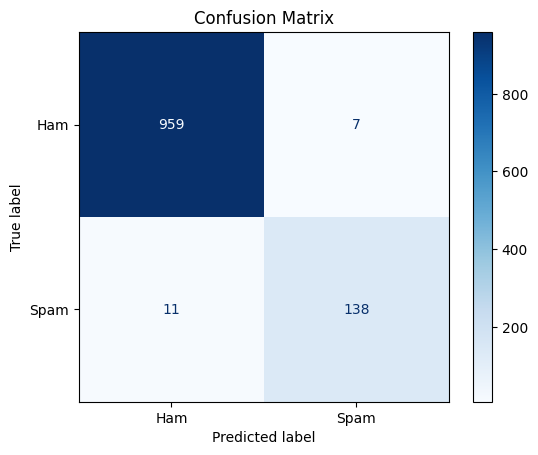

In [44]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [46]:
def filter_incoming_sms(message_text):
    seq = tokenizer.texts_to_sequences([message_text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    probability = model.predict(padded, verbose=0)[0][0]
    if probability > 0.5:
        return f"[SPAM ALERT ({probability*100:.1f}% Match)] -> Sent to Spam Folder."
    else:
        return f"[INBOX (Legitimate)] -> {message_text}"

In [47]:
print("\n--- Testing Live Message Filtering ---")
test_msg_1 = "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
result = filter_incoming_sms(test_msg_1)
print("Message:", test_msg_1)
print("Filter Result:", result)
if "LEGITIMATE" in result.upper():
    prediction = "HAM"
elif "SPAM" in result.upper():
    prediction = "SPAM"
else:
    prediction = "UNKNOWN"
print("Prediction:", prediction)


--- Testing Live Message Filtering ---
Message: I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
Filter Result: [INBOX (Legitimate)] -> I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
Prediction: HAM
